# Task 1.5 — Optional Experiments

In this notebook, we address all three optional experiment sub-tasks specified in the assignment:
1. **(a) t-SNE vs. UMAP Comparison:** Evaluate manifold representation and feature separability across 2D reduction algorithms.
2. **(b) Confused Class Feature Similarity Analysis:** Analyze feature space similarities between classes that ResNet-152 frequently confuses (e.g., *cat* vs *dog*, *automobile* vs *truck*).
3. **(c) ResNet-152 vs. ResNet-18 Feature Quality Comparison:** Contrast feature representations, cluster tightness, and inter-class margin separation between 152-layer (2048-d) and 18-layer (512-d) architectures.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import torch
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from task1_resnet152.src.data import get_cifar10_loaders
from task1_resnet152.src.model import load_resnet152, replace_head
from task1_resnet152.src.train import extract_features
from task1_resnet152.src.visualize import (
    plot_layer_tsne_individual,
    plot_model_comparison,
    plot_cross_model_class_similarity,
    plot_cluster_metrics_comparison,
    plot_confusion_and_similarity
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
train_loader, val_loader = get_cifar10_loaders(batch_size=256)

class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Load Pre-trained ResNet-152 and ResNet-18 Models
m152 = load_resnet152(pretrained=True)
m152 = replace_head(m152, 10)
m152.to(device)

m18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
m18.fc = torch.nn.Linear(m18.fc.in_features, 10)
m18.to(device)

# Extract Average Pooling Feature Vectors for CIFAR-10 Validation Set
feats152, labels = extract_features(m152, val_loader, device=device)
feats18, _ = extract_features(m18, val_loader, device=device)

feats152_np = feats152.cpu().numpy()
feats18_np = feats18.cpu().numpy()
labels_np = labels.cpu().numpy()

c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Extracting features:   0%|          | 0/40 [00:00<?, ?it/s]C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA0\atml-assignment0\task1_resnet152\src\train.py:146: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_cuda):


### Part (a) — Compare t-SNE vs. UMAP in Representing Feature Separability
Side-by-side 2D projections contrasting t-SNE and UMAP feature representations for ResNet-152 and ResNet-18 with discrete class legends.

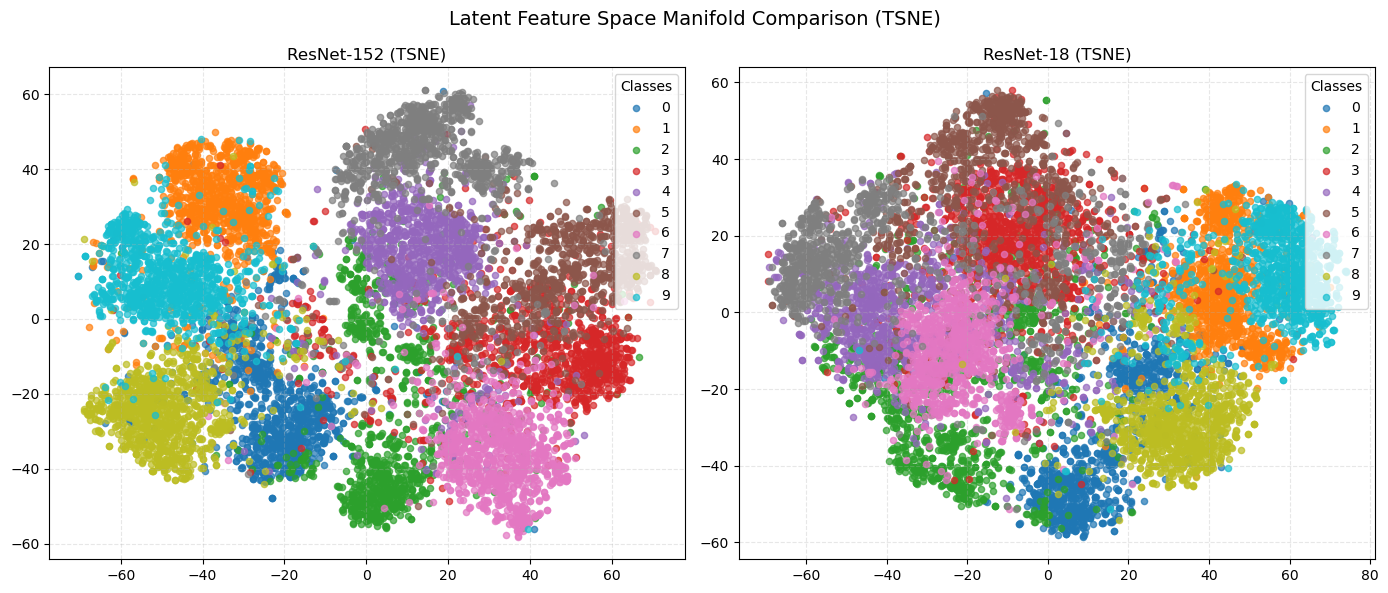

c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


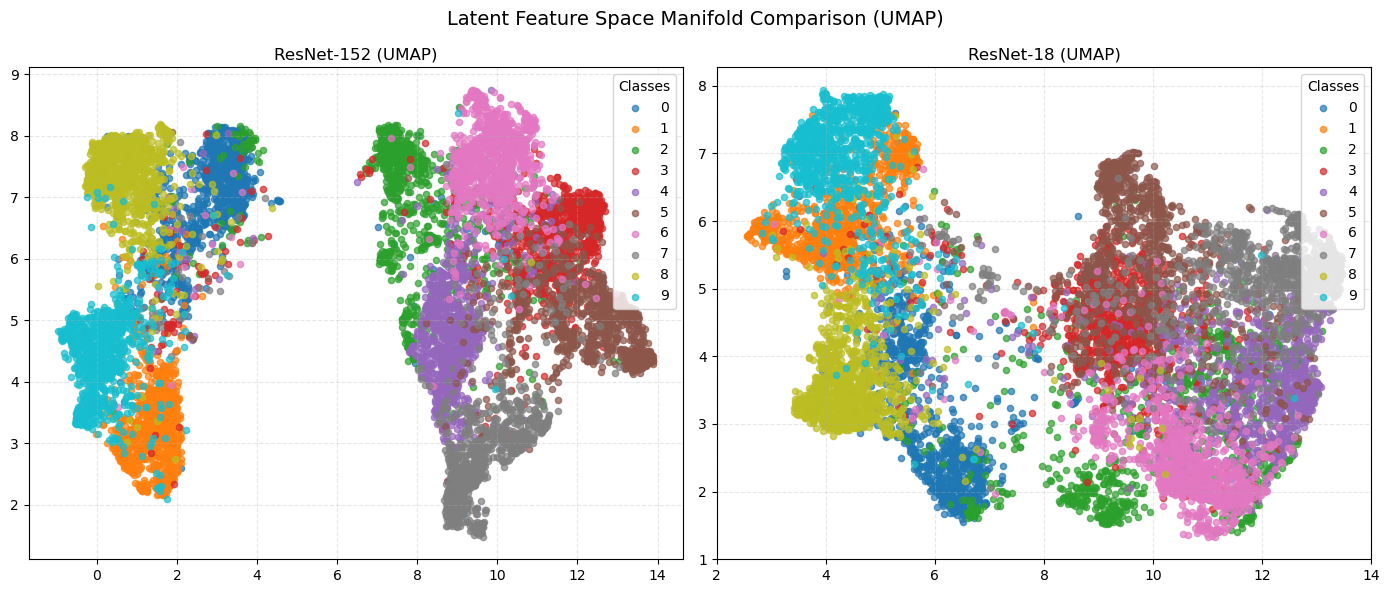

In [2]:
# Comparative t-SNE Projection Grid
plot_model_comparison(
    feats152_np,
    feats18_np,
    labels_np,
    title1="ResNet-152",
    title2="ResNet-18",
    method='tsne',
    save_path="../results/figures/resnet152_vs_resnet18_tsne.png"
)

# Comparative UMAP Projection Grid
plot_model_comparison(
    feats152_np,
    feats18_np,
    labels_np,
    title1="ResNet-152",
    title2="ResNet-18",
    method='umap',
    save_path="../results/figures/resnet152_vs_resnet18_umap.png"
)

### Part (b) — Analyze Feature Similarities Between Confused Classes
Normalized confusion matrix paired with class centroid cosine similarity matrix for ResNet-152 to analyze misclassification patterns.

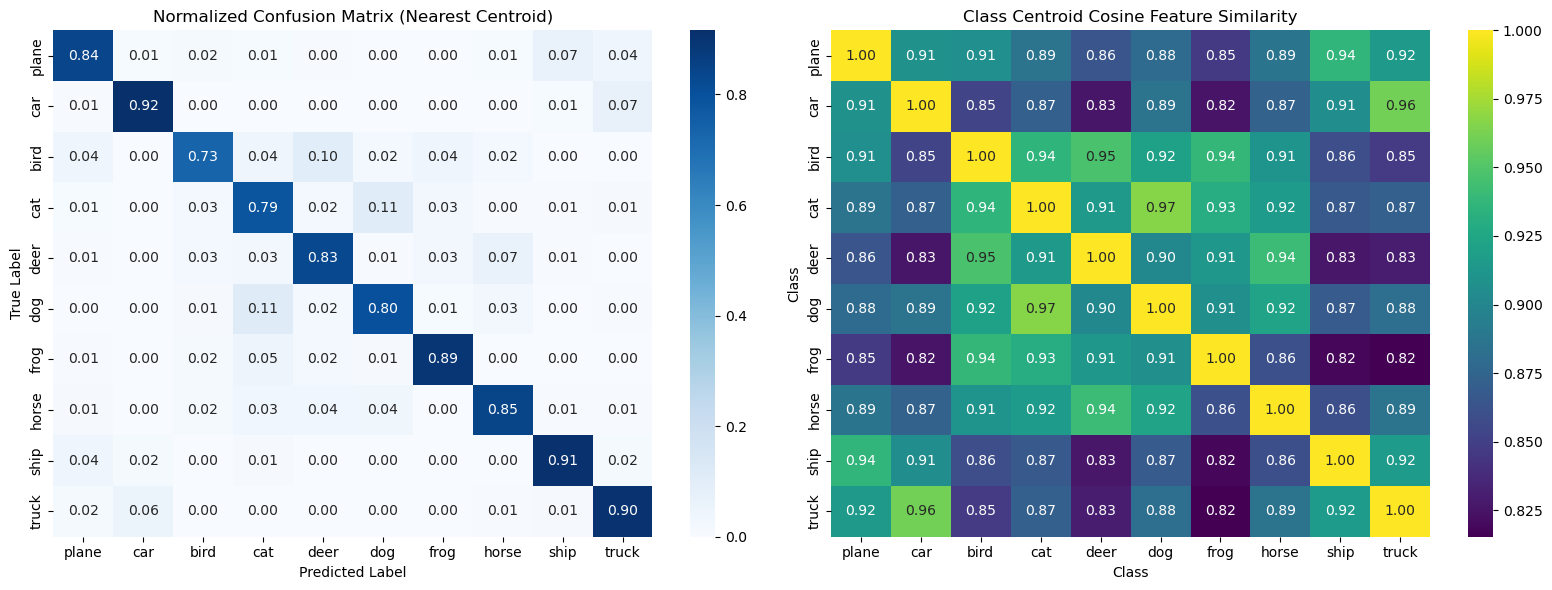

In [3]:
# Evaluate confusion matrix and class centroid cosine similarity for ResNet-152
plot_confusion_and_similarity(
    m152,
    val_loader,
    class_names,
    device=device,
    save_path="../results/figures/resnet152_confusion_and_similarity.png"
)

### Part (c) — Compare Feature Quality: ResNet-152 vs. Shallower ResNet-18
Individual t-SNE scatter plots, cross-model class centroid similarity matrix, and quantitative clustering metrics.

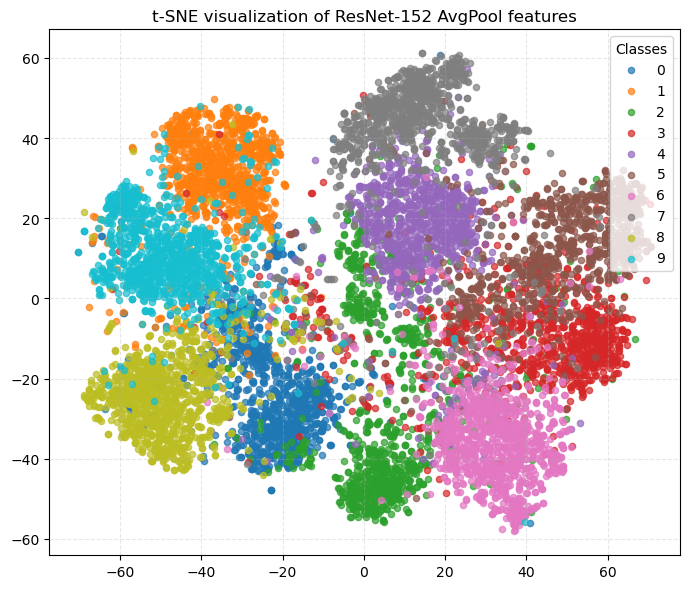

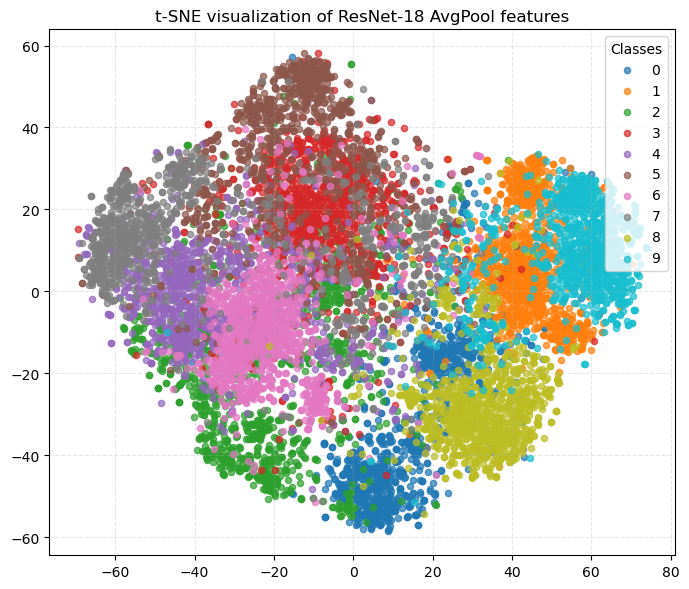

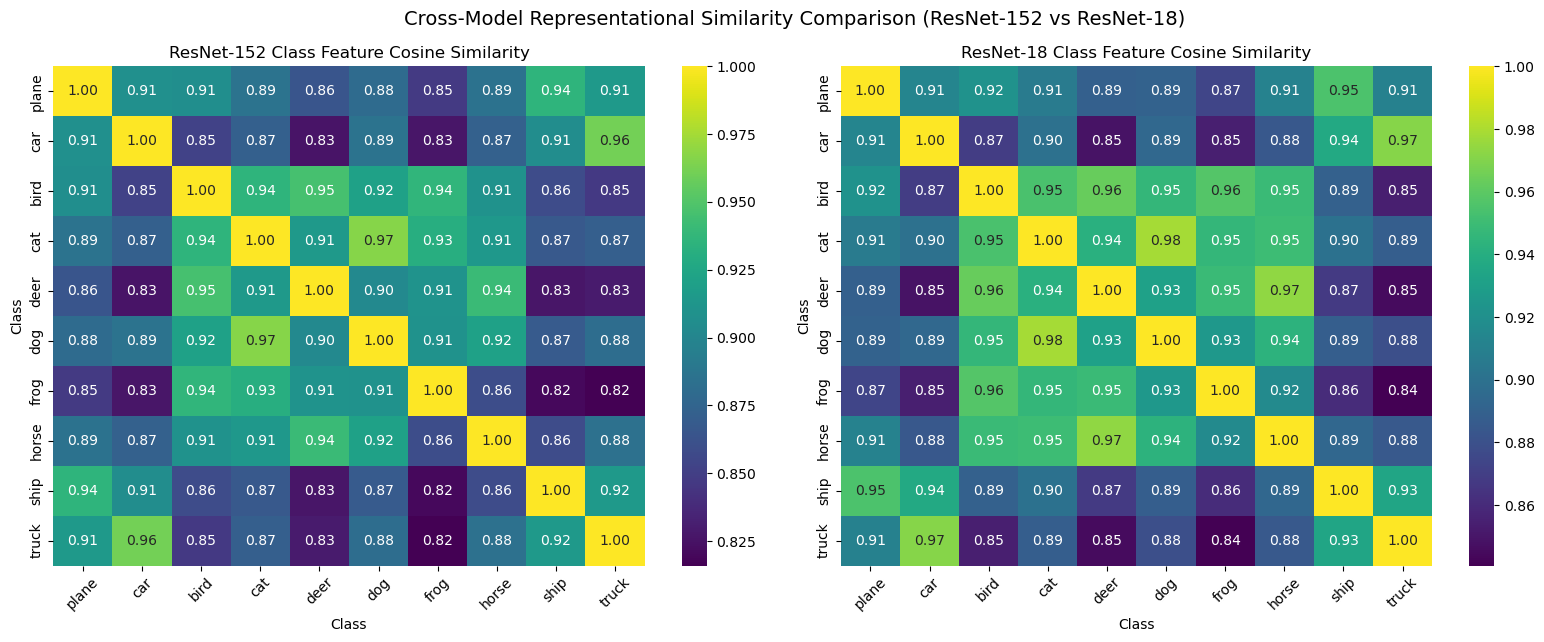

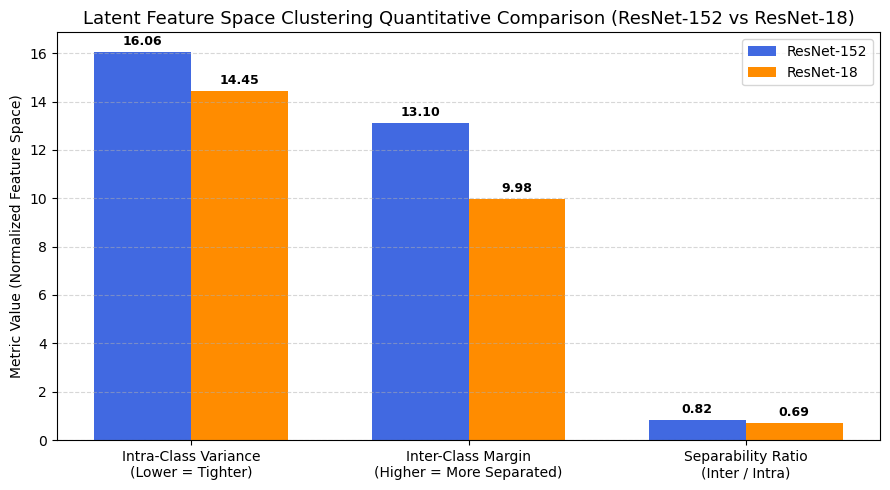

In [4]:
# Individual Single-Model t-SNE Scatter Plots
plot_layer_tsne_individual(
    feats152_np,
    labels_np,
    layer_name="ResNet-152 AvgPool",
    save_path="../results/figures/resnet152_tsne_individual.png"
)

plot_layer_tsne_individual(
    feats18_np,
    labels_np,
    layer_name="ResNet-18 AvgPool",
    save_path="../results/figures/resnet18_tsne_individual.png"
)

# Cross-Model Class Centroid Cosine Similarity Matrix
plot_cross_model_class_similarity(
    feats152_np,
    feats18_np,
    labels_np,
    class_names,
    title1="ResNet-152",
    title2="ResNet-18",
    save_path="../results/figures/resnet152_vs_resnet18_similarity.png"
)

# Quantitative Cluster Tightness & Margin Separation Comparison
plot_cluster_metrics_comparison(
    feats152_np,
    feats18_np,
    labels_np,
    title1="ResNet-152",
    title2="ResNet-18",
    save_path="../results/figures/resnet152_vs_resnet18_metrics.png"
)